# What a convolution is

Lesson 9 ended on a promise. Every network in it treated the 64 pixels of a
digit as 64 unrelated numbers: permute them consistently across the whole
dataset and nothing in that lesson would notice. This lesson is about what you
get by refusing to throw the arrangement away.

Meridian Instruments, whose sensors ran through lesson 9, cuts them from
silicon wafers. Each die is photographed and graded, and a die is rejected
when it carries a **defect** — a scratch a few pixels long, or a bright
particle. The defect looks the same wherever it lands, and that single
sentence is the entire argument for convolution.

This notebook implements the operation in NumPy, checks the two properties it
is built for, and counts what it costs. Keras does not appear until notebook
02. Handout sections 2 to 5.

## 1. Setup

In [1]:
# pip install numpy==1.26.4 pandas==2.1.1 matplotlib==3.8.0 scikit-learn==1.3.1 scipy==1.11.3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import correlate2d

from wafer_data import (make_wafer_images, make_defect_types,
                        TRUE_IMAGE_SIZE, TRUE_GRADER_ERROR_RATE,
                        TRUE_DEFECT_TYPES, TRUE_SCRATCH_LENGTH)

FIGURES = Path.cwd().parent / "Figures"
FIGURES.mkdir(exist_ok=True)

BLUE, TEAL, RUST, GOLD, PLUM = "#1F4E79", "#2E8B8B", "#B4483E", "#C9A227", "#7B4B94"
np.random.seed(10)

X, y, truth = make_wafer_images()
print(f"{len(X)} dies, each {X.shape[1]}x{X.shape[2]} pixels")
print(f"recorded as defective : {y.mean():.4f}")
print(f"truly defective       : {truth.mean():.4f}")
print(f"grades the station got wrong: {(y != truth).mean():.4f} "
      f"(designed: {TRUE_GRADER_ERROR_RATE})")
# Is 0.0255 a bug or a high draw? Do not guess — measure it at other seeds.
other_seeds = (11001, 11002, 11003, 12345, 10009, 10005, 555, 777)
other_rates = [(lambda b: (b[1] != b[2]).mean())(make_wafer_images(seed=s))
               for s in other_seeds]
spread = np.sqrt(TRUE_GRADER_ERROR_RATE * (1 - TRUE_GRADER_ERROR_RATE) / len(X))

print(f"\nThe design says {TRUE_GRADER_ERROR_RATE:.0%} of grades are wrong, so no "
      f"model can pass {1 - TRUE_GRADER_ERROR_RATE:.2f}.")
print(f"This batch drew {(y != truth).mean():.4f}. Eight other seeds give "
      f"{np.mean(other_rates):.4f}")
print(f"on average, and the binomial standard deviation at n={len(X)} is "
      f"{spread:.4f},")
print(f"so this batch sits {((y != truth).mean() - TRUE_GRADER_ERROR_RATE) / spread:.1f} "
      f"standard deviations high — a draw, not a bug.")
print(f"\nThe ceiling that matters is the one realised on whatever set you SCORE")
print(f"against. Notebook 02 measures it there rather than assuming it.")

4000 dies, each 24x24 pixels
recorded as defective : 0.5080
truly defective       : 0.5080
grades the station got wrong: 0.0255 (designed: 0.02)

The design says 2% of grades are wrong, so no model can pass 0.98.
This batch drew 0.0255. Eight other seeds give 0.0201
on average, and the binomial standard deviation at n=4000 is 0.0022,
so this batch sits 2.5 standard deviations high — a draw, not a bug.

The ceiling that matters is the one realised on whatever set you SCORE
against. Notebook 02 measures it there rather than assuming it.


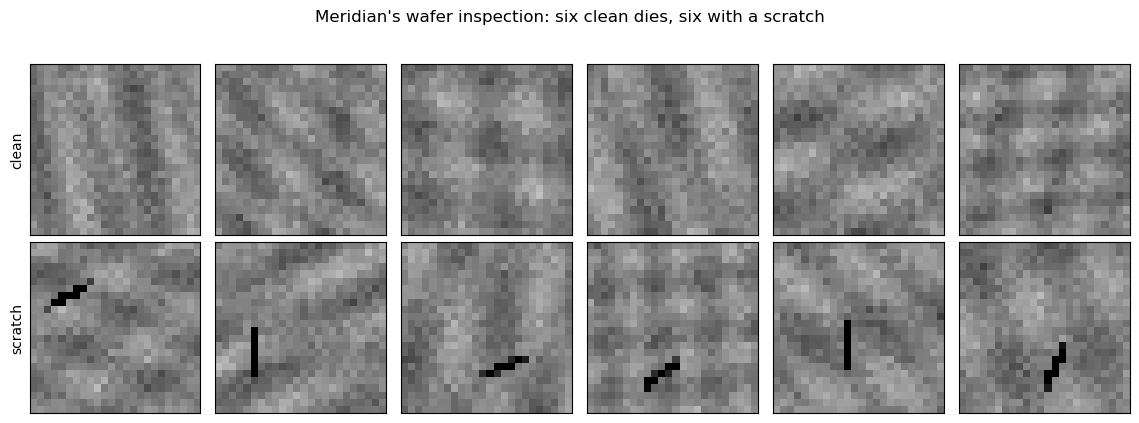

In [2]:
Xtype, ytype = make_defect_types(n_images=400)

fig, axes = plt.subplots(2, 6, figsize=(11.5, 4.2))
for col in range(6):
    clean = np.where(truth == 0)[0][col]
    dirty = np.where(truth == 1)[0][col]
    for row, index, name in ((0, clean, "clean"), (1, dirty, "scratch")):
        ax = axes[row, col]
        ax.imshow(X[index], cmap="gray", vmin=0, vmax=1)
        ax.set_xticks([]); ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(name, fontsize=10)
fig.suptitle("Meridian's wafer inspection: six clean dies, six with a scratch",
             y=1.01)
fig.tight_layout()
fig.savefig(FIGURES / "wafer_examples.png", dpi=150, bbox_inches="tight")
plt.show()

Two things about these images decide everything that follows.

**The defect is local.** It occupies a handful of pixels out of 576, and the
rest of the die is irrelevant to the verdict.

**The background is not flat.** Film thickness varies smoothly across a die,
so absolute brightness says nothing: a detector keyed to "is this pixel dark"
will fire on the dark half of every clean die. What marks a scratch is that it
is darker *than its immediate surroundings*.

Both point the same way. The useful question is asked of a small neighbourhood
at a time, and it is the **same question everywhere on the image**.

## 2. What lesson 9's network would have to learn

A dense layer connects every pixel to every unit. On a 24×24 image that is 576
weights per unit, and a unit that has learned to spot a scratch at one position
knows nothing whatsoever about the same scratch three pixels to the left — the
weights involved are different weights.

In [3]:
size = TRUE_IMAGE_SIZE
pixels = size * size

rows = []
for name, params in (
        ("dense layer, 256 units", pixels * 256 + 256),
        ("dense layer, 1024 units", pixels * 1024 + 1024),
        ("convolutional layer, 8 kernels of 3x3", 8 * (3 * 3) + 8),
        ("convolutional layer, 16 kernels of 3x3", 16 * (3 * 3) + 16),
        ("convolutional layer, 32 kernels of 5x5", 32 * (5 * 5) + 32)):
    rows.append({"layer": name, "parameters": params})
table = pd.DataFrame(rows).set_index("layer")
table["ratio to the 256-unit dense layer"] = (
    (pixels * 256 + 256) / table["parameters"]).round(1)
table

,parameters,ratio to the 256-unit dense layer
layer,,
"dense layer, 256 units",147712,1.0
"dense layer, 1024 units",590848,0.2
"convolutional layer, 8 kernels of 3x3",80,1846.4
"convolutional layer, 16 kernels of 3x3",160,923.2
"convolutional layer, 32 kernels of 5x5",832,177.5


Eighty parameters against a hundred and forty-seven thousand. The convolutional
layer does not have fewer parameters because it is smaller — it produces
**more** numbers than the dense layer does, one per position per kernel. It has
fewer because it uses *the same* nine weights at every position.

That is the whole trick, and it has a name: **weight sharing**. What it buys is
not compression. It is that one example of a scratch teaches the detector about
scratches everywhere, instead of about scratches at that one spot.

## 3. The operation, in eleven lines

A convolutional layer slides a small array of weights — the **kernel** — over
the image, and at every position writes down the weighted sum of the pixels it
covers.

$$(I * K)[r, c] = \sum_{i=0}^{f-1}\sum_{j=0}^{f-1} I[r + i,\; c + j]\; K[i, j]$$

Written that way it is *cross-correlation*; true convolution flips the kernel
first. Every deep learning library computes the version above and calls it
convolution, and since the kernel is learned the flip makes no difference to
anything. This course follows the library.

In [4]:
def convolve(image, kernel, padding=0, stride=1):
    """Slide `kernel` over `image` and write down the weighted sums."""
    if padding:
        image = np.pad(image, padding, mode="constant")
    f = kernel.shape[0]
    out_h = (image.shape[0] - f) // stride + 1
    out_w = (image.shape[1] - f) // stride + 1
    out = np.empty((out_h, out_w))
    for r in range(out_h):
        for c in range(out_w):
            patch = image[r * stride:r * stride + f, c * stride:c * stride + f]
            out[r, c] = np.sum(patch * kernel)
    return out


# Checked against scipy, which is a second implementation by other people.
probe_image = np.random.default_rng(0).normal(0, 1, (12, 12))
probe_kernel = np.random.default_rng(1).normal(0, 1, (3, 3))
mine = convolve(probe_image, probe_kernel)
theirs = correlate2d(probe_image, probe_kernel, mode="valid")
print(f"largest disagreement with scipy: {np.abs(mine - theirs).max():.3e}")
print(f"shapes: mine {mine.shape}, scipy {theirs.shape}")

largest disagreement with scipy: 8.882e-16
shapes: mine (10, 10), scipy (10, 10)


### The output size, worked out

With an $n \times n$ input, an $f \times f$ kernel, padding $p$ and stride $s$:

$$\text{output size} = \left\lfloor \frac{n + 2p - f}{s} \right\rfloor + 1$$

Two cases are worth memorising because they cover almost everything you will
write. A $3 \times 3$ kernel with $p = 1$ and $s = 1$ leaves the size
**unchanged** — that is what Keras calls `padding="same"`. And $s = 2$ roughly
halves it.

In [5]:
checks = []
for n, f, p, s in ((24, 3, 0, 1), (24, 3, 1, 1), (24, 5, 0, 1),
                   (24, 5, 2, 1), (24, 3, 1, 2), (24, 2, 0, 2)):
    formula = (n + 2 * p - f) // s + 1
    measured = convolve(np.zeros((n, n)), np.zeros((f, f)),
                        padding=p, stride=s).shape[0]
    checks.append({"n": n, "kernel f": f, "padding p": p, "stride s": s,
                   "formula": formula, "measured": measured,
                   "agree": formula == measured})
pd.DataFrame(checks).set_index("n")

,kernel f,padding p,stride s,formula,measured,agree
n,,,,,,
24,3,0,1,22,22,True
24,3,1,1,24,24,True
24,5,0,1,20,20,True
24,5,2,1,24,24,True
24,3,1,2,12,12,True
24,2,0,2,12,12,True


## 4. Kernels chosen by hand

Before training anything, it is worth seeing that a $3 \times 3$ array of nine
numbers really can express "darker than its surroundings". These three are
written down, not learned.

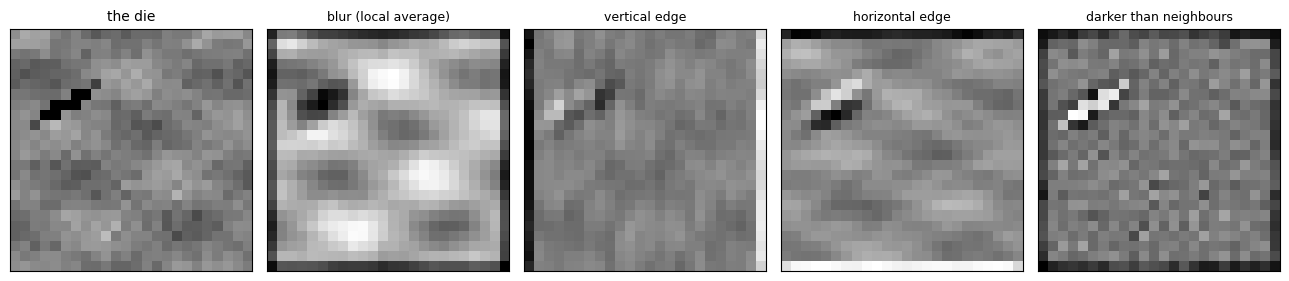

'darker than neighbours' response: strongest 3.129 at (8, 3)
  strongest response over a CLEAN die: 1.118


In [6]:
kernels = {
    "blur (local average)": np.ones((3, 3)) / 9,
    "vertical edge": np.array([[1., 0., -1.],
                               [2., 0., -2.],
                               [1., 0., -1.]]),
    "horizontal edge": np.array([[1., 2., 1.],
                                 [0., 0., 0.],
                                 [-1., -2., -1.]]),
    "darker than neighbours": np.array([[-1., -1., -1.],
                                        [-1., 8., -1.],
                                        [-1., -1., -1.]]) * -1,
}

example = X[np.where(truth == 1)[0][0]]
fig, axes = plt.subplots(1, 5, figsize=(13.0, 3.0))
axes[0].imshow(example, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("the die", fontsize=10)
for ax, (name, kernel) in zip(axes[1:], kernels.items()):
    response = convolve(example, kernel, padding=1)
    ax.imshow(response, cmap="gray")
    ax.set_title(name, fontsize=9)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
fig.savefig(FIGURES / "convolution_by_hand.png", dpi=150, bbox_inches="tight")
plt.show()

spotter = kernels["darker than neighbours"]
response = convolve(example, spotter, padding=1)
print(f"'darker than neighbours' response: strongest {response.max():.3f} "
      f"at {np.unravel_index(response.argmax(), response.shape)}")
print(f"  strongest response over a CLEAN die: "
      f"{convolve(X[np.where(truth == 0)[0][0]], spotter, padding=1).max():.3f}")

The last kernel sums to zero, and that is not decoration: a kernel whose
weights sum to zero gives exactly zero on any *constant* patch, whatever its
brightness. It therefore ignores the smooth background variation entirely and
responds only to local contrast. Nine numbers, and the hardest part of the
problem is already handled.

## 5. The property the whole idea rests on

**Equivariance to translation.** Shift the input, and the output shifts by the
same amount — the response does not change, it moves. This is a claim that can
be checked rather than asserted.

In [7]:
def shift(image, dr, dc):
    return np.roll(np.roll(image, dr, axis=0), dc, axis=1)


base = convolve(example, spotter, padding=1)
worst = 0.0
for dr, dc in ((0, 3), (2, 0), (-4, 5), (6, -2)):
    moved = convolve(shift(example, dr, dc), spotter, padding=1)
    # Compare away from the border, where the roll wraps around.
    inner = slice(8, 16)
    disagreement = np.abs(moved[inner, inner]
                          - shift(base, dr, dc)[inner, inner]).max()
    worst = max(worst, disagreement)
    print(f"  shift by ({dr:+d}, {dc:+d}): largest difference between "
          f"'convolve then shift' and 'shift then convolve' = {disagreement:.2e}")
print(f"\nworst: {worst:.2e} — the two orders are the same operation")

  shift by (+0, +3): largest difference between 'convolve then shift' and 'shift then convolve' = 0.00e+00
  shift by (+2, +0): largest difference between 'convolve then shift' and 'shift then convolve' = 0.00e+00
  shift by (-4, +5): largest difference between 'convolve then shift' and 'shift then convolve' = 0.00e+00
  shift by (+6, -2): largest difference between 'convolve then shift' and 'shift then convolve' = 0.00e+00

worst: 0.00e+00 — the two orders are the same operation


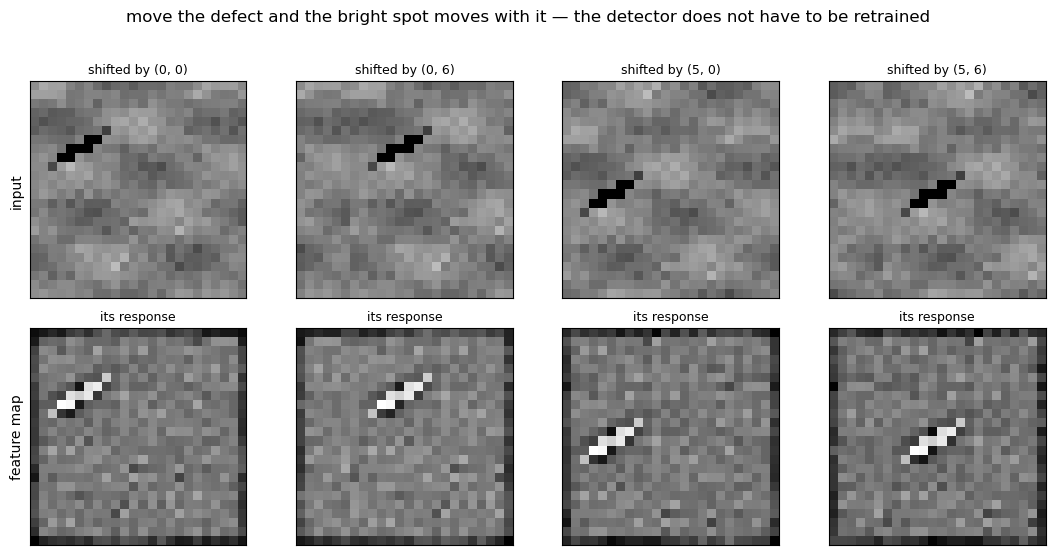

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(11.0, 5.4))
for col, (dr, dc) in enumerate(((0, 0), (0, 6), (5, 0), (5, 6))):
    moved = shift(example, dr, dc)
    axes[0, col].imshow(moved, cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(f"shifted by ({dr}, {dc})", fontsize=9)
    axes[1, col].imshow(convolve(moved, spotter, padding=1), cmap="gray")
    axes[1, col].set_title("its response", fontsize=9)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].set_ylabel("input", fontsize=10)
axes[1, 0].set_ylabel("feature map", fontsize=10)
fig.suptitle("move the defect and the bright spot moves with it — "
             "the detector does not have to be retrained", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES / "equivariance.png", dpi=150, bbox_inches="tight")
plt.show()

A dense layer has no such property, and this is the difference the whole
lesson turns on. Shift the input by one pixel and every one of a dense unit's
576 weights is now multiplied by a different pixel: the unit's output is not
shifted, it is *unrelated*. Notebook 02 measures what that costs.

## 6. Pooling: from "where" to "whether"

Equivariance says the response moves with the defect. For grading a die we do
not want the response to move — we want one number saying whether a strong
response occurred **anywhere**. That is what pooling does: take the maximum
over a window and throw the position away.

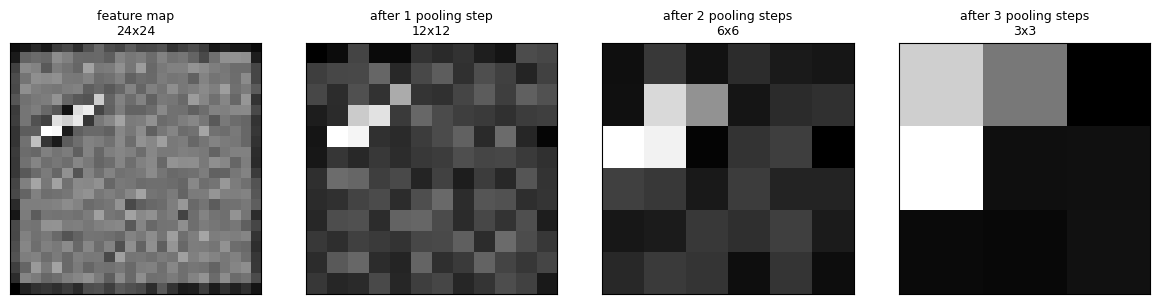

the strongest response survives every step:
  feature map                  max 3.129
  after 1 pooling step         max 3.129
  after 2 pooling steps        max 3.129
  after 3 pooling steps        max 3.129


In [9]:
def max_pool(feature_map, size=2):
    h = feature_map.shape[0] // size
    w = feature_map.shape[1] // size
    return feature_map[:h * size, :w * size].reshape(
        h, size, w, size).max(axis=(1, 3))


stack = [("feature map", base)]
current = base
for step in range(3):
    current = max_pool(current)
    stack.append((f"after {step + 1} pooling step{'s' if step else ''}", current))

fig, axes = plt.subplots(1, len(stack), figsize=(12.0, 3.0))
for ax, (name, arr) in zip(axes, stack):
    ax.imshow(arr, cmap="gray")
    ax.set_title(f"{name}\n{arr.shape[0]}x{arr.shape[1]}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
fig.savefig(FIGURES / "pooling.png", dpi=150, bbox_inches="tight")
plt.show()

print("the strongest response survives every step:")
for name, arr in stack:
    print(f"  {name:28s} max {arr.max():.3f}")

The maximum is unchanged at every step — that is the point of taking a
maximum. What is lost is *where* it was, and for grading a die that is exactly
the information we are happy to discard.

Pooling also does two other things worth naming. It shrinks the map, so the
next layer's kernels cover a larger area of the original image for the same
cost — stack enough and a $3 \times 3$ kernel is looking at most of the die.
And it makes the answer **invariant** rather than merely equivariant to small
shifts: move the defect by one pixel and after pooling the output is often
literally identical.

## Summary

- A convolutional layer applies **the same** small kernel at every position.
  What that buys is not fewer parameters but shared evidence: one example
  teaches the detector everywhere.
- 80 parameters against 147,712, for a layer that outputs *more* numbers.
- Output size is $\lfloor (n + 2p - f)/s \rfloor + 1$; a $3 \times 3$ kernel
  with $p = 1$ preserves the size.
- A kernel whose weights sum to zero ignores constant brightness and responds
  only to local contrast, which is what the uneven wafer background requires.
- Convolution is **equivariant** to translation — checked here rather than
  asserted, and away from the borders the two orders of operation agree
  *exactly*, to the last bit. Pooling turns that into **invariance**, which is
  what a grading decision actually needs.

Notebook 02 hands the kernels to gradient descent and measures what the
arrangement was worth.